# Market Regime Detection using K-Means Clustering

## Objective

The objective of this notebook is to identify hidden market regimes within Bitcoin price behavior using unsupervised machine learning.

After transforming the original financial features through Principal Component Analysis (PCA), we apply K-Means clustering to group observations with similar characteristics.

These clusters may represent different market conditions such as:

- Bull Markets
- Bear Markets
- Sideways Markets
- Transitional Periods

Unlike supervised learning, no regime labels are provided to the model. Instead, the algorithm discovers patterns directly from the data.

The resulting clusters will serve as the foundation for the market regime detection system developed in this project.

Clustering is performed on the PCA-transformed dataset rather than the original engineered features.

The PCA components provide a compact representation of market behavior by combining information from returns, volatility, and momentum while reducing redundancy between variables.

Using the PCA feature space can improve cluster separation and facilitate the identification of meaningful market regimes.

-----

## Load PCA Dataset

In this section, we load the dataset generated during the PCA stage.

This dataset contains the principal components that will be used as inputs for the clustering algorithm.

The objective is to verify that the PCA transformation was successfully saved and can be loaded correctly for the market regime detection process.

In [1]:
# Import libraries
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import os 
import sys

# Ruta absoluta a la raíz del proyecto
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from config import *

In [2]:
# Load PCA DataSet
if len(ASSETS) != 1:
    raise ValueError(
        "This notebook is designed for single-asset analysis."
    )

asset_name = (
    ASSETS[0]
    .lower()
    .replace("-", "_")
)

pca_path =(
    f"{PROCESSED_DATA_PATH}/"
    f"{asset_name}_pca.csv"
)

df = pd.read_csv(pca_path)

df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

------

## Dataset Verification

Before applying clustering algorithms, we verify the structure of the PCA-transformed dataset.

The dataset should contain the principal components generated during the dimensionality reduction stage and will serve as the feature space used to identify potential market regimes.

In [3]:
# Vrification of the df
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 3065 entries, 2018-01-31 to 2026-06-22
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PC1     3065 non-null   float64
 1   PC2     3065 non-null   float64
 2   PC3     3065 non-null   float64
dtypes: float64(3)
memory usage: 95.8 KB


,PC1,PC2,PC3
count,3.065000e+03,3.065000e+03,3.065000e+03
mean,-1.159124e-17,3.709195e-17,-2.318247e-17
std,1.128224e+00,1.001394e+00,8.516445e-01
min,-1.054665e+01,-1.706852e+00,-5.187152e+00
25%,-5.492385e-01,-6.763457e-01,-4.641618e-01
50%,-3.282028e-02,-2.004149e-01,-4.235113e-02
75%,5.477539e-01,4.728205e-01,4.116788e-01
max,6.087710e+00,4.982666e+00,5.821992e+00


### Interpretation

The PCA-transformed dataset contains 3,065 observations represented by three principal components (PC1, PC2, and PC3), providing a compact representation of market behavior suitable for clustering analysis.

No missing values were detected, and all principal components are stored as numerical variables, satisfying the requirements of the K-Means algorithm.

The principal components are centered around zero, which is expected after feature standardization and PCA transformation. Additionally, the decreasing standard deviations across components reflect the variance hierarchy identified during the PCA stage, where PC1 captures the largest proportion of information and PC3 captures the smallest.

Overall, the dataset appears clean, consistent, and ready for unsupervised learning. The principal component space will be used to identify potential market regimes through clustering techniques.

-----

## Clustering Workflow Overview

Clustering is an unsupervised learning technique used to identify groups of observations that exhibit similar characteristics.

In this project, clustering is applied to the PCA-transformed feature space to discover potential market regimes. Rather than using predefined labels, the algorithm will automatically group observations based on their similarity in terms of the principal components extracted during the dimensionality reduction stage.

The clustering workflow consists of the following steps:

1. Determine an appropriate number of clusters.
2. Train the clustering model.
3. Assign each observation to a cluster.
4. Visualize cluster separation in PCA space.
5. Interpret the resulting market regimes.

The ultimate objective is to identify recurring patterns of market behavior that may correspond to distinct financial conditions such as bullish, bearish, or high-volatility environments.

### Methods of clustering 
The Elbow Method and Silhouette Score provide complementary perspectives on clustering quality.

The Elbow Method evaluates cluster compactness by measuring the within-cluster sum of squares, while the Silhouette Score evaluates how well separated the clusters are from one another.

Using both metrics reduces the risk of selecting a cluster configuration that is either overly fragmented or insufficiently distinct, leading to a more robust identification of market regimes.

-----

## Cluster Selection Analysis

Before training the final clustering model, multiple values of K will be evaluated to determine an appropriate number of clusters.

The evaluation will be based on both the Elbow Method and the Silhouette Score. Together, these metrics provide complementary information regarding cluster compactness and cluster separation.

The objective is to identify candidate cluster configurations that can later be analyzed from a financial perspective.

In [4]:
# Import clustering tools
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [5]:
# Store evaluation metrics

inertia_scores = []
silhouette_scores = []
k_values = []

In [6]:
# Evaluate different cluster configurations
for k in range(MIN_CLUSTERS, MAX_CLUSTERS + 1):
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(df)

    inertia_scores.append(kmeans.inertia_)

    silhouette_scores.append(silhouette_score(df, cluster_labels))

    k_values.append(k)

In [7]:
# Create evaluation table
evaluation_df = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia_scores,
    "Silhouette Score": silhouette_scores
})

evaluation_df

,K,Inertia,Silhouette Score
0,2,7057.932230,0.298920
1,3,5503.171739,0.310379
2,4,4709.181632,0.318086
3,5,4235.243400,0.307491
4,6,3790.364363,0.248393
5,7,3499.990021,0.247846
6,8,3242.453492,0.229861
7,9,3016.390171,0.245322
8,10,2834.339394,0.248465


### Interpretation

The clustering evaluation was performed using both the Elbow Method (Inertia) and the Silhouette Score across cluster configurations ranging from K=2 to K=10.

As expected, inertia decreases monotonically as the number of clusters increases, indicating improved within-cluster compactness. However, inertia alone cannot determine the optimal number of clusters because additional clusters will almost always reduce the metric.

The Silhouette Score provides additional insight by evaluating the balance between cluster cohesion and separation. The highest score was obtained for K=4 (0.318), while K=3 and K=5 also produced competitive results.

These results suggest that the most promising cluster configurations lie between three and five clusters. Consequently, these candidate values will be further analyzed before selecting the final market regime structure.

-----

## Elbow Method Analysis

The Elbow Method is used to evaluate how cluster compactness changes as the number of clusters increases.

For each value of K, the within-cluster sum of squares (Inertia) is calculated. Lower inertia values indicate that observations are closer to their assigned centroids.

The objective is to identify a point where adding additional clusters provides diminishing improvements. This point, commonly referred to as the "elbow", represents a potential candidate for the optimal number of clusters.

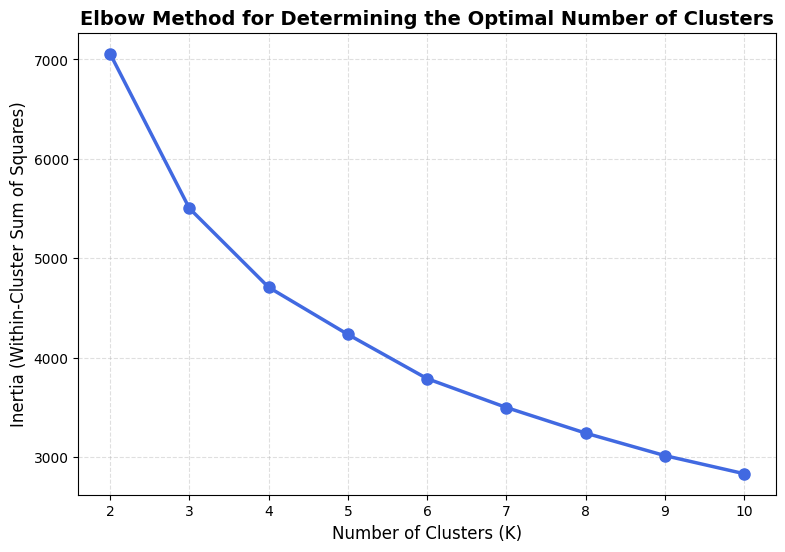

In [8]:
# Plot the Elbow Method

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertia_scores,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue"
)

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)


### Initial Observation
Looking at the metric evaluation table, we observe a steady drop in **Inertia** as the number of clusters ($K$) increases from 2 to 10. 
* A massive drop occurs moving from $K=2$ ($7057.93$) to $K=3$ ($5260.62$), and then to $K=4$ ($4709.18$).
* After $K=4$, the margin of decrease begins to shrink significantly (e.g., changing by only ~200-300 points per step).

This suggests an optimal structural change ("elbow") likely exists around **$K=3$ or $K=4$**. To confirm the exact location of this inflection point, we generate a visual Elbow plot below.

#### Chart With The Interpretation

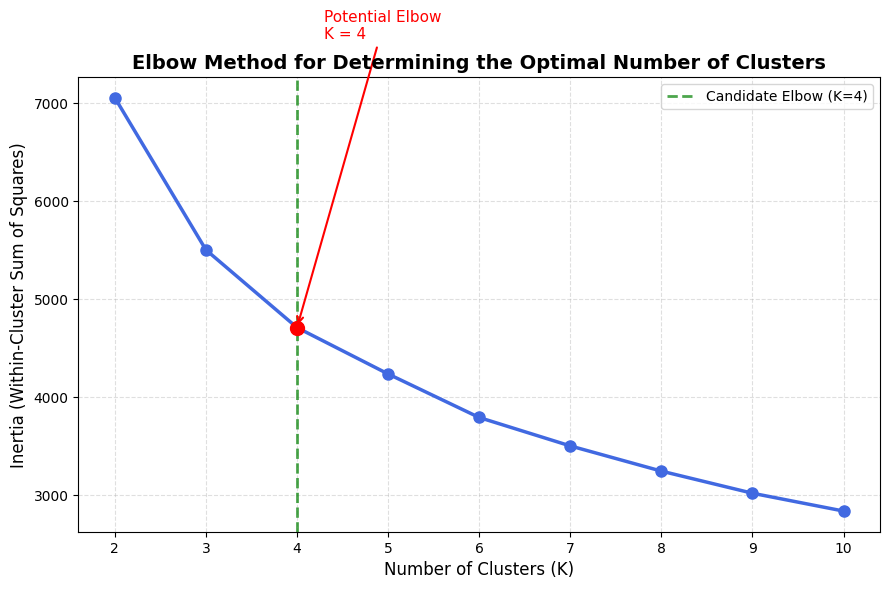

In [9]:
# Plot the Elbow Method

plt.figure(figsize=(9, 6))

plt.plot(
    k_values,
    inertia_scores,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="royalblue"
)

plt.xlabel("Number of Clusters (K)", fontsize=12)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=12)
plt.title("Elbow Method for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

# Highlight the candidate elbow
candidate_k = 4 
plt.axvline(
    x = candidate_k,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Candidate Elbow (K=4)"
)

plt.scatter(
    candidate_k,
    inertia_scores[candidate_k - MIN_CLUSTERS],
    color="red",
    s=100,
    zorder=5
)

plt.annotate(
    "Potential Elbow\nK = 4",
    xy=(candidate_k, inertia_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, inertia_scores[0] + 600),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5
    ),
    fontsize=11,
    color="red"
)

plt.legend()

plt.tight_layout()
plt.show()

### Final Interpretation: Elbow Analysis
The visual plot confirms that the steepest rate of descent occurs between $K=2$ and $K=4$. Beyond $K=4$, the curve visibly flattens into a linear trajectory with diminishing returns. 

While $K=3$ presents a minor inflection point, $K=4$ provides the cleanest "elbow" where the trade-off between cluster tightness (low inertia) and model complexity is minimized. This points to 4 distinct variance-structures in the underlying Bitcoin data.

------

## Silhouette Score Analysis

The Silhouette Score is used to evaluate the quality of cluster separation and cohesion across different values of K.

For each observation, the silhouette coefficient measures how similar it is to its own cluster compared to the next closest cluster. The average score across the entire dataset ranges from -1 to +1, where higher values indicate that data points are well-matched to their own regime and distinctly separated from neighboring regimes.

The objective is to identify a peak in the score curve. Unlike inertia, which always decreases as K increases, the Silhouette Score helps us prevent over-clustering by highlighting the configuration where the market regimes remain structurally distinct and do not blend into each other.

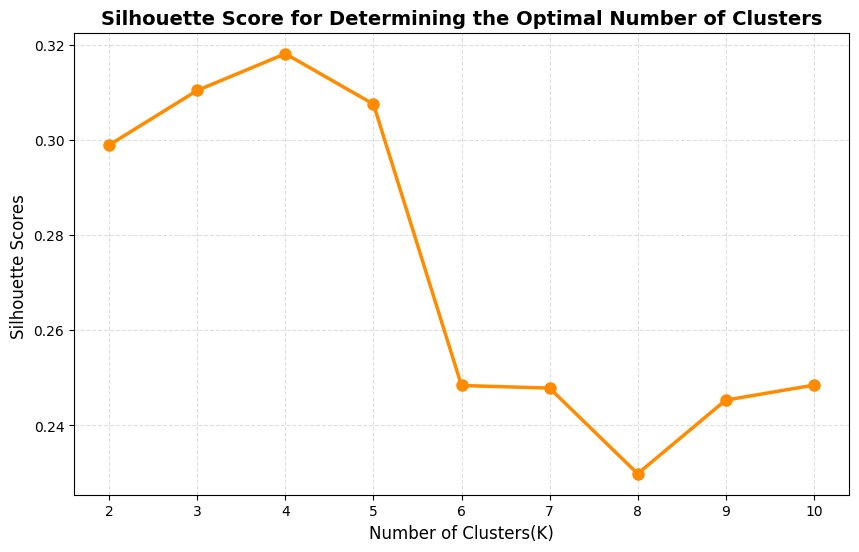

In [10]:
# Plot the Silhouette Scores
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    silhouette_scores,
    marker = 'o',
    markersize = 8,
    linewidth = 2.5,
    color = 'darkorange'
)

plt.xlabel("Number of Clusters(K)", fontsize=12)
plt.ylabel("Silhouette Scores ", fontsize=12)
plt.title("Silhouette Score for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

### Initial Observation
The Silhouette Score evaluates cluster separation and cohesion. Looking at our tabular data:
* $K=2$ starts at $0.298$, showing moderate structural separation.
* The score increases as we add clusters, pointing to better-defined groupings.
* It reaches its global maximum exactly at **$K=4$ with a score of $0.318$**.

Any further increase in clusters ($K \ge 5$) causes the score to deteriorate rapidly, indicating that the algorithm is forcing arbitrary splits on well-defined groups. We will plot this curve next to identify the peak explicitly.

#### Chart With The Interpretation

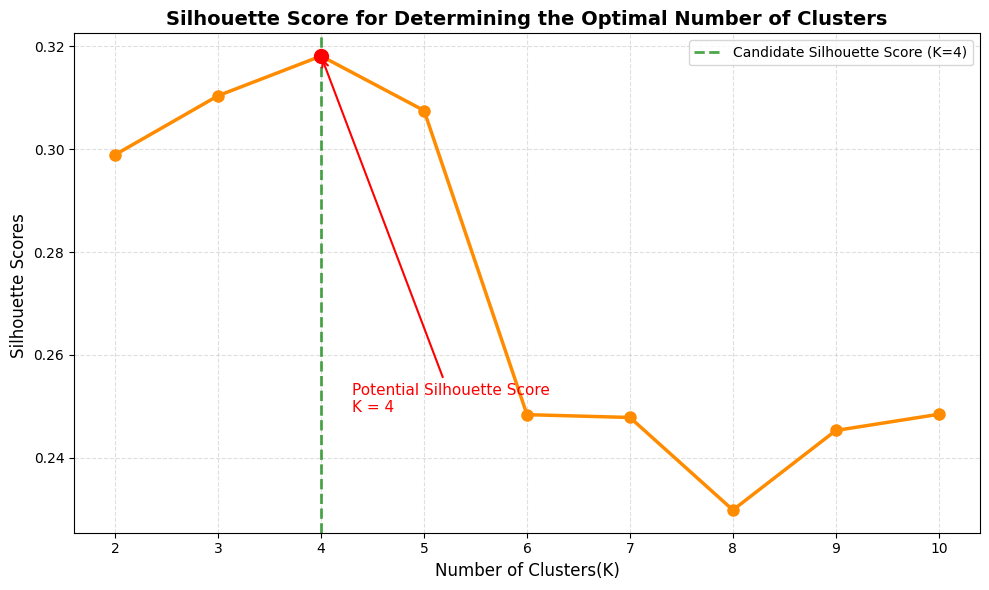

In [11]:
# Plot the Silhouette Scores
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    silhouette_scores,
    marker = 'o',
    markersize = 8,
    linewidth = 2.5,
    color = 'darkorange'
)

plt.xlabel("Number of Clusters(K)", fontsize=12)
plt.ylabel("Silhouette Scores ", fontsize=12)
plt.title("Silhouette Score for Determining the Optimal Number of Clusters",
          fontsize=14,
          fontweight="bold")

plt.xticks(k_values)
plt.grid(True, linestyle="--", alpha=0.4)

# Highlight the candidate silhouette score  
candidate_k = 4
plt.axvline(
    x = candidate_k,
    color = "green",
    linestyle = "--",
    linewidth=2,
    alpha=0.7,
    label = "Candidate Silhouette Score (K=4)"
)

plt.scatter(
    candidate_k, 
    silhouette_scores[candidate_k - MIN_CLUSTERS],
    color = "red",
    s = 100,
    zorder = 5
)

plt.annotate(
    "Potential Silhouette Score\nK = 4",
    xy=(candidate_k, silhouette_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, silhouette_scores[0] - 0.05),
    arrowprops=dict(
        arrowstyle="->",
        color="red",
        lw=1.5
    ),
    fontsize=11,
    color="red"
)

plt.legend()

plt.tight_layout()
plt.show()

### Final Interpretation: Silhouette Analysis
The standalone Silhouette curve shows a clear, undeniable peak at **$K=4$**. 

In financial regime detection, a peak like this is highly valuable because it proves that at $K=4$, the market environments (e.g., high volatility bear vs. low volatility bull) are maximally distinct from one another. Moving to $K=5$ or higher causes severe cluster overlap, decreasing our confidence in the detected states.

----

## Combined Metric Analysis

The Elbow Method and the Silhouette Score evaluate different aspects of clustering quality.

Rather than relying on a single metric, both results are analyzed together to identify the most promising cluster configurations before selecting the final K-Means model.

To make a robust final decision on the optimal number of market regimes, we evaluate the Elbow Method and the Silhouette Score simultaneously.

Relying on a single metric can lead to suboptimal choices—Inertia alone may favor an excessively high number of clusters, while the Silhouette Score might favor an oversimplified structure. By overlaying both metrics, we look for a point of convergence: a value of K that sits at a clear "elbow" of diminishing returns for internal tightness, while simultaneously capturing a local or global peak in cluster separation.

This dual-perspective approach ensures our final market states are both mathematically optimized and practically viable for asset allocation.

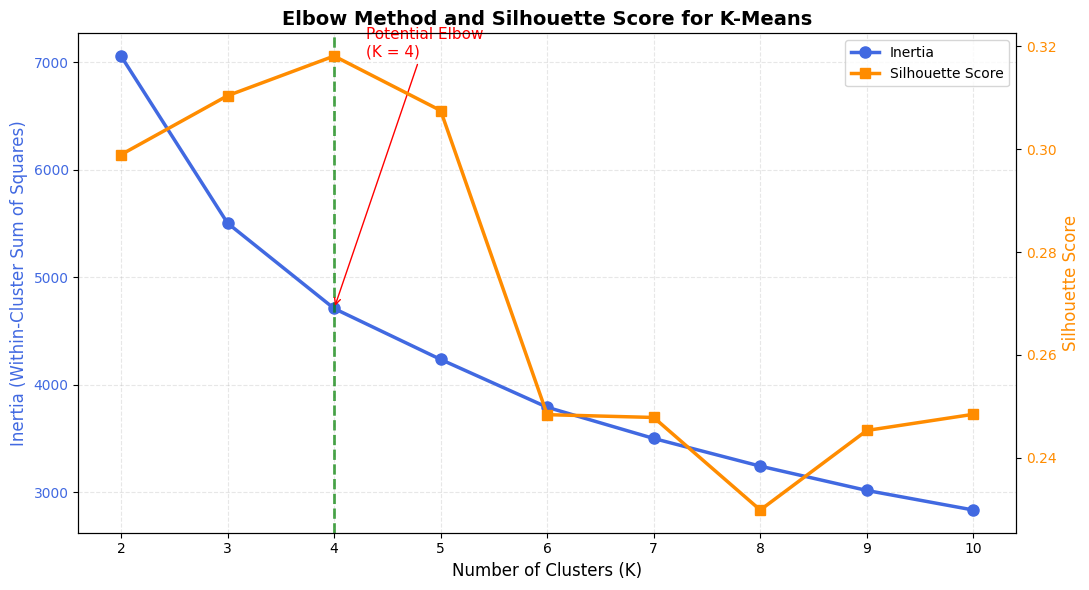

In [12]:
# Plot Elbow Method and Silhouette Score

fig, ax1 = plt.subplots(figsize=(11, 6))

# -------------------------
# Elbow Method (Inertia)
# -------------------------
ax1.plot(
    k_values,
    inertia_scores,
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="royalblue",
    label="Inertia"
)

ax1.set_xlabel("Number of Clusters (K)", fontsize=12)
ax1.set_ylabel("Inertia (Within-Cluster Sum of Squares)",
               fontsize=12,
               color="royalblue")

ax1.tick_params(axis="y", labelcolor="royalblue")
ax1.grid(True, linestyle="--", alpha=0.3)

# Highlight the proposed elbow
candidate_k = 4

ax1.axvline(
    candidate_k,
    color="green",
    linestyle="--",
    linewidth=2,
    alpha=0.7
)

ax1.annotate(
    "Potential Elbow\n(K = 4)",
    xy=(candidate_k, inertia_scores[candidate_k - MIN_CLUSTERS]),
    xytext=(candidate_k + 0.3, inertia_scores[0]),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=11,
    color="red"
)

# -------------------------
# Silhouette Score
# -------------------------
ax2 = ax1.twinx()

ax2.plot(
    k_values,
    silhouette_scores,
    marker="s",
    linewidth=2.5,
    markersize=7,
    color="darkorange",
    label="Silhouette Score"
)

ax2.set_ylabel(
    "Silhouette Score",
    fontsize=12,
    color="darkorange"
)

ax2.tick_params(axis="y", labelcolor="darkorange")

# -------------------------
# Legends
# -------------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper right"
)

plt.title(
    "Elbow Method and Silhouette Score for K-Means",
    fontsize=14,
    weight="bold"
)

plt.tight_layout()
plt.show()

### Interpretation
By evaluating both metrics simultaneously, we arrive at a robust mathematical and financial conclusion:

1. **Convergence of Evidence:** The Elbow Method identifies **$K=4$** as the point of diminishing returns for minimizing internal variance. Concurrently, the Silhouette Score achieves its maximum peak exactly at **$K=4$**, confirming optimal group separation.
2. **Financial Viability:** Choosing $K=4$ maps beautifully to real-world macroeconomic market states for an asset like Bitcoin:
   * **Bull Market (Expansionary)**
   * **Bear Market (Capitulation/Contraction)**
   * **Sideways/Accumulation (Low Volatility)**
   * **High-Volatility Transitional/Distribution Phase**

**Conclusion:** We formally select **$K=4$** as our structural framework for detecting market regimes in the subsequent steps.

----

## Candidate Cluster Configurations

The previous analyses identified several plausible values for the number of clusters. Since no single metric is sufficient to determine the optimal clustering configuration, the candidate values are evaluated collectively.

This comparison combines the Elbow Method, the Silhouette Score, and the practical interpretability of the resulting market regimes. The objective is to justify the final number of clusters before training the K-Means model.

In [13]:
# Candidate cluster configuration
candidate_df = evaluation_df.copy()

candidate_df["Elbow Candidate"] = candidate_df["K"].between(3,5)

candidate_df["Silhouette Rank"] = candidate_df["Silhouette Score"].rank(ascending=True, method="dense").astype(int)

candidate_df["Selected"] = candidate_df["K"] == 4

candidate_df

,K,Inertia,Silhouette Score,Elbow Candidate,Silhouette Rank,Selected
0,2,7057.932230,0.298920,False,6,False
1,3,5503.171739,0.310379,True,8,False
2,4,4709.181632,0.318086,True,9,True
3,5,4235.243400,0.307491,True,7,False
4,6,3790.364363,0.248393,False,4,False
5,7,3499.990021,0.247846,False,3,False
6,8,3242.453492,0.229861,False,1,False
7,9,3016.390171,0.245322,False,2,False
8,10,2834.339394,0.248465,False,5,False


### Interpretation

The candidate evaluation indicates that K=3, K=4, and K=5 represent the most promising clustering configurations. These values fall within the elbow region, where additional clusters begin to provide diminishing improvements in compactness.

Among these candidates, K=4 achieved the highest Silhouette Score, indicating the best balance between cluster cohesion and separation. Although K=3 and K=5 also produced competitive results, their silhouette values were slightly lower.

Configurations with six or more clusters were discarded because the Silhouette Score decreased considerably while the reduction in inertia became progressively smaller. This suggests that additional clusters increase model complexity without providing a meaningful improvement in cluster quality.

Based on both quantitative metrics and the expected interpretability of market regimes, K=4 is selected as the final clustering configuration for the remainder of this project.

----

## Final Cluster Selection

The candidate configurations identified in the previous section are now compared to determine the final clustering model.

Rather than selecting the number of clusters solely from a single evaluation metric, the Elbow Method is first used to define a candidate search region. Within this region, the configuration with the highest Silhouette Score is selected as the final model.

This hierarchical decision process balances cluster compactness, cluster separation, and model interpretability while reducing the risk of selecting an unnecessarily complex clustering solution.

In [14]:
# Candidate elbow identified from the Elbow Method
# This value was selected after visually analyzing
# the Elbow curve.

elbow_k = 4

In [15]:
# Candidate cluster configurations

candidate_range = range(
    max(MIN_CLUSTERS, elbow_k - 1),
    min(MAX_CLUSTERS, elbow_k + 1) + 1
)

candidate_df = evaluation_df[
    evaluation_df["K"].isin(candidate_range)
].copy()

In [16]:
# Rank candidate models according to the
# Silhouette Score

candidate_df["Silhouette Rank"] = (
    candidate_df["Silhouette Score"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)


In [17]:
# Select the best candidate

optimal_k = candidate_df.loc[
    candidate_df["Silhouette Score"].idxmax(),
    "K"
]

OPTIMAL_N_CLUSTERS = int(optimal_k)

print(
    f"Selected number of clusters: "
    f"{OPTIMAL_N_CLUSTERS}"
)

candidate_df["Selected"] = (
    candidate_df["K"] == optimal_k
)

candidate_df

Selected number of clusters: 4


,K,Inertia,Silhouette Score,Silhouette Rank,Selected
1,3,5503.171739,0.310379,2,False
2,4,4709.181632,0.318086,1,True
3,5,4235.243400,0.307491,3,False


### Interpretation

The candidate evaluation confirms that K = 3, K = 4, and K = 5 represent the most plausible clustering configurations identified during the previous analyses. These values belong to the elbow region, where additional clusters provide progressively smaller reductions in inertia.

Among these candidates, K = 4 achieved the highest Silhouette Score, indicating the best balance between cluster compactness and cluster separation. Although K = 3 and K = 5 also produced competitive results, neither surpassed K = 4 in terms of overall clustering quality.

Consequently, K = 4 is selected as the final clustering configuration for the remainder of the project. This value provides a well-balanced trade-off between statistical performance, model complexity, and the expected interpretability of the resulting financial market regimes.

The selected value will be used in the following sections to train the final K-Means model, assign market regime labels to each observation, and analyze the characteristics of each identified market state.

-----

## Training the Final K-Means Model

After selecting the optimal number of clusters, the final K-Means model can now be trained using the PCA-transformed dataset.

The selected number of clusters is obtained from the previous evaluation process, ensuring that the clustering model is trained using the configuration that provides the best balance between cluster compactness and separation.

The trained model will later be used to assign a market regime label to every observation and to analyze the characteristics of each identified cluster.

In [18]:
# Initialize the final K-Means model

kmeans = KMeans(
    n_clusters=OPTIMAL_N_CLUSTERS, 
    random_state=RANDOM_SEED,
    n_init="auto"
)

# Train the clustering model

kmeans.fit(df)

# Assign a cluster label to each observation

cluster_labels = kmeans .predict(df)

# Create copy of the PCA dataset including the assigned cluster

cluster_df = df.copy()

cluster_df["Cluster_Id"] = cluster_labels

# Display the first observations 

print(
    f"Model trained successfully with "
    f"{OPTIMAL_N_CLUSTERS} clusters."
)

print(
    f"Total observations clustered: "
    f"{len(cluster_df)}"
)

cluster_df.head()

Model trained successfully with 4 clusters.
Total observations clustered: 3065


,PC1,PC2,PC3,Cluster_Id
Date,,,,
2018-01-31,-0.467024,2.720811,-0.489859,0
2018-02-01,-3.517646,2.316925,1.308062,2
2018-02-02,-2.324336,2.535690,-0.295359,2
2018-02-03,-0.973506,2.825677,-2.173690,0
2018-02-04,-3.865690,2.111764,0.714665,2


In [19]:
# Let's verify the assigments 
cluster_df["Cluster_Id"].value_counts().sort_index()

Cluster_Id
0     414
1    1683
2     410
3     558
Name: count, dtype: int64

In [20]:
# Verify the percentage it represents each one 
cluster_distribution = (
    cluster_df["Cluster_Id"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution

Cluster_Id
0    13.51
1    54.91
2    13.38
3    18.21
Name: proportion, dtype: float64

### Interpretation

The K-Means model was successfully trained using the selected configuration of four clusters. All 3,065 observations in the PCA-transformed dataset were assigned to a cluster, confirming that the clustering process completed without errors.

The distribution of observations across the clusters indicates that each cluster contains a meaningful number of samples. Although Cluster 1 represents approximately 55% of the dataset, the remaining clusters also contain several hundred observations, providing sufficient data for subsequent statistical analysis.

The unequal cluster sizes suggest that some market conditions occur more frequently than others, which is consistent with the behavior of financial markets where certain regimes may dominate over extended periods while others appear only during specific events.

At this stage, the cluster identifiers represent only numerical group labels. Their financial interpretation will be performed in the following sections by analyzing the statistical characteristics of each identified cluster.

----

## Cluster Distribution Analysis

Before analyzing the spatial separation of the identified clusters, it is useful to examine how observations are distributed across them.

A balanced cluster distribution is not required for a good clustering model; however, extremely small or empty clusters may indicate over-segmentation or poor cluster formation. This visualization provides an initial assessment of the representativeness of each identified market regime.

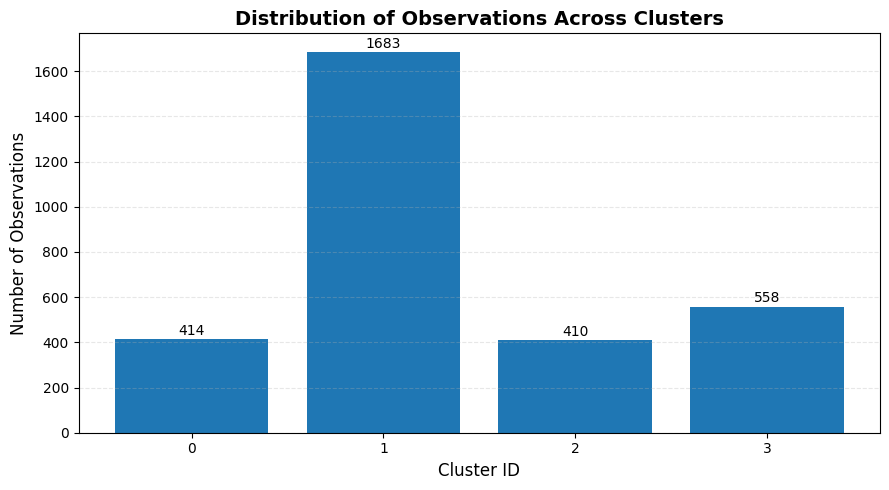

In [21]:
# Number of observation per cluster
cluster_counts = (
    cluster_df["Cluster_Id"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title(
    "Distribution of Observations Across Clusters",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cluster ID", fontsize=12)

plt.ylabel("Number of Observations", fontsize=12)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

# Add labels above each bar
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 20,
        f"{int(height)}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

### Interpretation

The distribution of observations indicates that all four clusters contain a substantial number of samples, confirming that the selected clustering configuration does not produce empty or negligible groups.

Cluster 1 represents the largest proportion of the dataset, accounting for approximately 55% of all observations. This suggests that one market regime dominates the analyzed historical period, while the remaining clusters capture less frequent but still significant market conditions.

Although the cluster sizes are not perfectly balanced, this behavior is expected in financial time series, where certain market regimes persist for extended periods whereas others are associated with specific events or transitions. The resulting distribution provides sufficient observations within every cluster to support subsequent statistical analysis and financial interpretation.

-----

## Cluster Visualization in PCA Space

To better understand how the K-Means model partitions the data, the identified clusters are visualized in the reduced PCA feature space.

Each point represents a single observation projected onto the first two principal components, while colors indicate the assigned cluster. Since the first principal components capture most of the variance in the transformed dataset, this visualization provides an intuitive representation of the cluster structure learned by the algorithm.

The cluster centroids are also displayed to illustrate the central position of each identified market regime.

In [22]:
# Extract centroid coordinates
centroids = kmeans.cluster_centers_

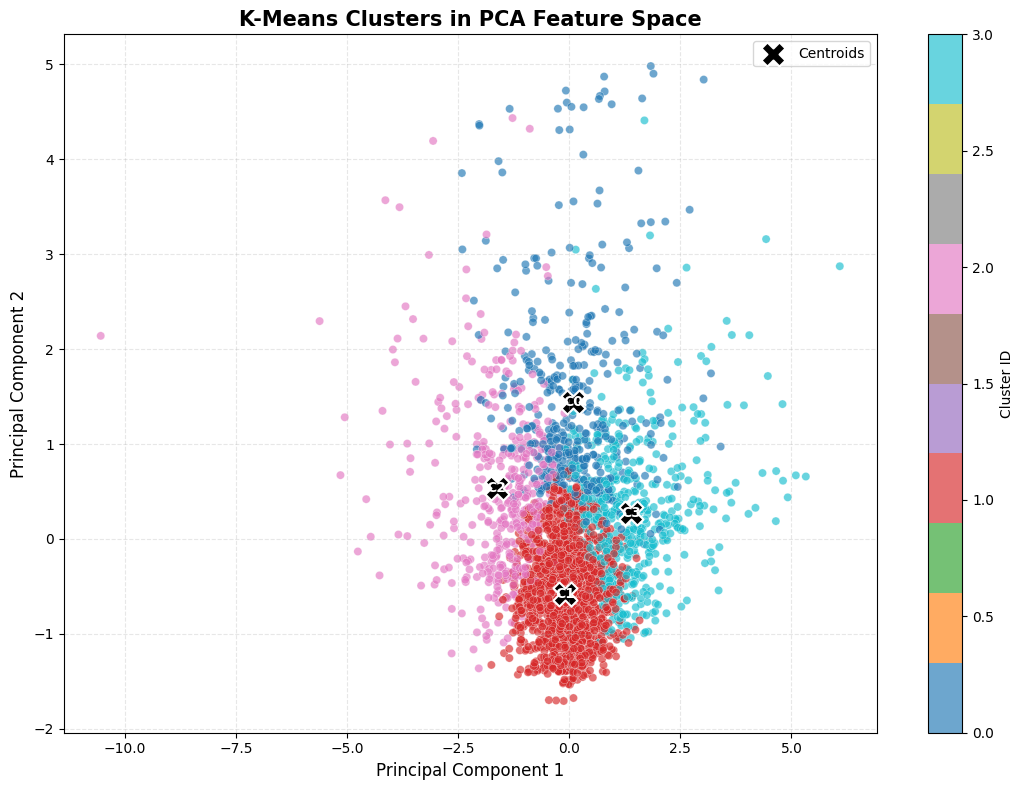

In [27]:
# Visualization of clusters in PCA space

plt.figure(figsize=(11, 8))

scatter = plt.scatter(
    cluster_df["PC1"],
    cluster_df["PC2"],
    c=cluster_df["Cluster_Id"],
    cmap="tab10",
    alpha=0.65,
    s=35,
    edgecolors="white",
    linewidth=0.3
)

# Plot centroids

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300,
    color="black",
    edgecolors="white",
    linewidth=1.5,
    label="Centroids"
)

# Label every centroid

for cluster_id in range(len(centroids)):

    plt.text(
        centroids[cluster_id, 0],
        centroids[cluster_id, 1],
        f"C{cluster_id}",
        fontsize=10,
        fontweight="bold",
        color="white",
        ha="center",
        va="center"
    )

plt.title(
    "K-Means Clusters in PCA Feature Space",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Principal Component 1",
    fontsize=12
)

plt.ylabel(
    "Principal Component 2",
    fontsize=12
)

plt.grid(
    linestyle="--",
    alpha=0.3
)

plt.legend()

cbar = plt.colorbar(scatter)

cbar.set_label(
    "Cluster ID"
)

plt.tight_layout()

plt.show()